In [1]:
import warnings

import os
import torch
import pickle
import numpy as np
import pandas as pd
import os.path as osp
from tqdm import tqdm

import torchvision
import albumentations as A
from functools import reduce
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.datasets import DatasetBuilder
from src.models.classifiers import SimpleCNNtorch, build_resnet50
from src.evaluation.local_instability import perturb_sample
from src.evaluation.local_instability import calculate_sparsity, calculate_ssim
from src.utils import seed_everything, get_config, load_model_weights
from src.utils import evaluate_classification_model, plot_boxplot

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
I0000 00:00:1775430977.161585  220329 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
seed_everything()
warnings.filterwarnings("ignore", category=UserWarning)

In [12]:
# repo_path = r'D:\PycharmProjects\CF-Robustness-Benchmark'
repo_path = r'/teamspace/studios/this_studio/CF-Robustness-Benchmark'
config_path = r'configs/ldce_derma_multi.yaml'
config = get_config(osp.join(repo_path, config_path))

NUM_CLASSES = config.data.num_classes
DEVICE = config.accelerator if torch.cuda.is_available() else 'cpu'
TASK = 'binary' if NUM_CLASSES == 2 else 'multiclass'
TARGET_CLASS = 4
TARGET_CLASS_IND = 2

print(f"Device: {DEVICE} | Classes: {NUM_CLASSES} | Task: {TASK} | Target class: {TARGET_CLASS}")

Device: cpu | Classes: 4 | Task: multiclass | Target class: 4


In [13]:
ds_builder = DatasetBuilder(config)
ds_builder.setup()
train_loader, val_loader, test_loader = ds_builder.get_dataloaders()

In [14]:
imgs = ds_builder.train_dataset.data.imgs  # (N, H, W, 3), uint8 [0, 255]
mean = imgs.mean(axis=(0, 1, 2)) / 255.0   # per-channel mean
std = imgs.std(axis=(0, 1, 2)) / 255.0     # per-channel std

test_loader.dataset.transform = A.Compose(
            [A.Normalize(mean=mean.tolist(), std=std.tolist())])

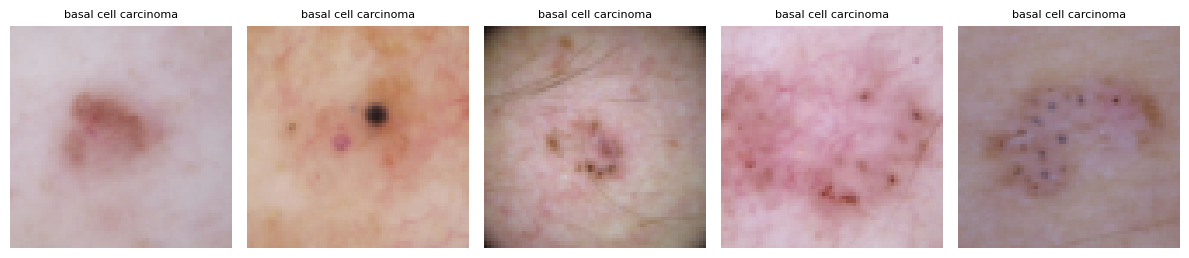

In [15]:
def denormalize(img_tensor, mean, std):
    """Reverse ImageNet normalization for visualization. Input: (C, H, W) tensor."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1)
    
MEAN = mean.tolist()
STD  = std.tolist()
n_samples = 5
class_names = ds_builder.class_encodings
fig, axs = plt.subplots(1, n_samples, figsize=(12, 4))

sample_batch = next(iter(test_loader))
images, labels = sample_batch[0][:n_samples], sample_batch[1][:n_samples]

for i in range(n_samples):
    display_img = denormalize(images[i], mean=MEAN, std=STD).permute(1, 2, 0).numpy()
    axs[i].imshow(display_img)
    axs[i].set_title(class_names[labels[i].item()], fontsize=8)
    axs[i].axis('off')
plt.tight_layout()
plt.show()

In [16]:
os.makedirs(config.save_dir, exist_ok=True)
class_names = ds_builder.class_encodings
ds_name = config.data.name
print(ds_name, class_names)

dermamnist {0: 'basal cell carcinoma', 1: 'benign keratosis-like lesions', 2: 'melanoma', 3: 'melanocytic nevi'}


# Load the classifier

In [17]:
config.classifier.checkpoints_path

'/teamspace/studios/this_studio/CF-Robustness-Benchmark/notebooks/experiments/dermamnist_classification/multiclass/checkpoints/derma_resnet50_acc=0.74.pth'

In [18]:
baseline_classifier = build_resnet50(num_classes=config.data.num_classes, **config.classifier.args)
                                # img_size=config.data.img_size)
load_model_weights(baseline_classifier, 
                    weights_path=config.classifier.checkpoints_path, 
                    lightning_used=False)
baseline_classifier.eval()
evaluate_classification_model(baseline_classifier, test_loader, config.data.num_classes, device=DEVICE)
baseline_classifier = baseline_classifier.to(DEVICE)

Accuracy for the test dataset: 74.351%


# Load generated explanations and their original instances

In [19]:
with open(osp.join(config.save_dir, 'results_original.pkl'), 'rb')  as f:
    results_original = pickle.load(f)

In [20]:
with open(osp.join(config.save_dir, 'results_perturbed.pkl'), 'rb')  as f:
    results_perturbed = pickle.load(f)

In [23]:
noise_magnitudes = [0.005, 0.01, 0.015, 0.02, 0.025]
n = 100

resize_fn = torchvision.transforms.Resize(config.data.img_size)
# prepare_input = lambda x: resize_fn(x)[0:1, ...]
get_prediction  = lambda x: torch.argmax(baseline_classifier(x.unsqueeze(0)), axis=-1).item()

results_original = sorted(results_original, key=lambda x: x['unique_id'])

factuals = [item['image'] for item in results_original]
factuals_preds = list(map(get_prediction, factuals))

cfes =  [item['image_cf'] for item in results_original]
cfes_preds =  list(map(get_prediction, cfes))

factuals_pert = {noise: []  for noise in noise_magnitudes}
factuals_pert_predictions = {noise: []  for noise in noise_magnitudes}

cfes_pert = {noise: []  for noise in noise_magnitudes}
cfes_pert_predictions = {noise: []  for noise in noise_magnitudes}

results_perturbed = sorted(results_perturbed, key=lambda x: x['unique_id'])


for item in results_perturbed:
    noise_level = item['epsilon']
    factual_pert = item['image_perturbed']
    cfe_pert = item['image_cf_perturbed']
    
    factuals_pert[noise_level].append(factual_pert)
    cfes_pert[noise_level].append(cfe_pert)

    factuals_pert_predictions[noise_level].append(get_prediction(factual_pert))
    cfes_pert_predictions[noise_level].append(get_prediction(cfe_pert))

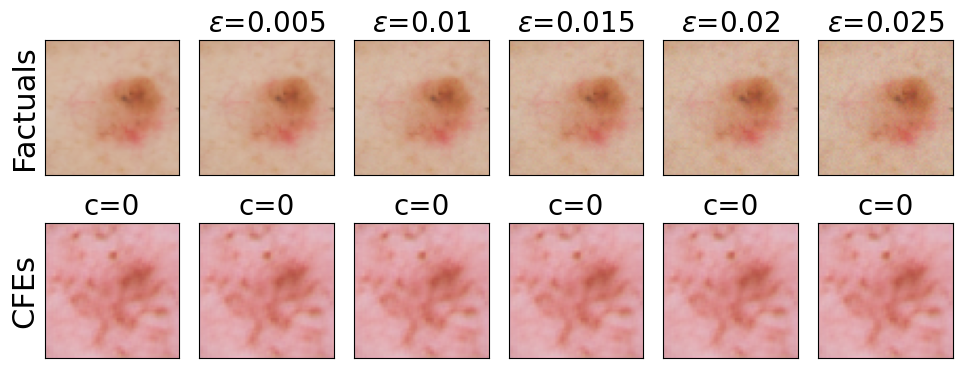

In [37]:
n_rows = 2
n_cols = 6

ind = 15

factuals_vis = [factuals[ind]] + [factuals_pert[noise][ind] for noise in noise_magnitudes]
cfes_vis = [cfes[ind]] + [cfes_pert[noise][ind] for noise in noise_magnitudes]
cfes_vis_pred = [cfes_preds[ind]] + [cfes_pert_predictions[noise][ind] for noise in noise_magnitudes]

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 4), sharex=True, sharey=True)
for j in range(n_cols):
    # noise = noise_magnitudes[]
    pert_image = factuals_vis[j].squeeze()
    axs[0, j].imshow(pert_image.permute(1, 2, 0))
    if j > 0:
        noise = noise_magnitudes[j-1]
        axs[0, j].set_title('$\\epsilon$={}'.format((noise)), fontsize=20) 
    
    axs[1, j].imshow(cfes_vis[j].squeeze().permute(1, 2, 0))
    if j == 0:
        axs[0, j].set_ylabel('Factuals', fontsize=22)
        axs[1, j].set_ylabel('CFEs', fontsize=22)

    pred = cfes_vis_pred[j]
    axs[1, j].set_title(f'c={TARGET_CLASS if pred == TARGET_CLASS_IND else pred}', fontsize=20)

plt.tight_layout()
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);
plt.savefig(osp.join(config.save_dir, f'ldce_{TARGET_CLASS}_cfes.png'))
plt.show()

# Local Instability

In [40]:
indices = np.where(np.asarray(cfes_preds) == TARGET_CLASS_IND)[0]
validity = indices.shape[0] / len(cfes_preds)
print(f'Validity: ',  validity)

Validity:  0.9439252336448598


In [42]:
validity_list = []
for noise in noise_magnitudes:
    cfes_pert_pred = cfes_pert_predictions[noise]
    indices = np.where(np.asarray(cfes_pert_pred) == TARGET_CLASS_IND)[0]
    validity = indices.shape[0] / len(cfes_pert_pred)
    validity_list.append(validity)
    print(f'Validity for the added noise level {noise}: ',  validity)

fname = f'{ds_name.lower()}_{TARGET_CLASS}_validity.pkl'
with open(osp.join(config.save_dir, fname), 'wb') as f:
    pickle.dump(validity_list, f)

Validity for the added noise level 0.005:  0.9439252336448598
Validity for the added noise level 0.01:  0.9439252336448598
Validity for the added noise level 0.015:  0.9439252336448598
Validity for the added noise level 0.02:  0.9439252336448598
Validity for the added noise level 0.025:  0.9439252336448598


In [43]:
instability_l1_list = []
ssim_list = []

for noise, cfe_pert_list in cfes_pert.items():
    l1_temp = []
    ssim_temp = []
    for i in range(len(cfes)):
        cfe = cfes[i]
        cfe_pert = cfe_pert_list[i]
        cfe_pred  =  cfes_preds[i]
        cfe_pert_pred = cfes_pert_predictions[noise][i]

        if cfe_pred == TARGET_CLASS_IND and cfe_pert_pred == TARGET_CLASS_IND:
            
            l1_distance = sum(abs(cfe.flatten() - cfe_pert.flatten())).item() # np.linalg.norm(cf.flatten() - cf_perturbed.flatten(), ord=1)
            l1_temp.append(l1_distance)

            ssim = calculate_ssim(cfe.unsqueeze(0), cfe_pert.unsqueeze(0)).item()
            ssim_temp.append(ssim)

    instability_l1_list.append(l1_temp)
    ssim_list.append(ssim_temp)

threshold = np.percentile(instability_l1_list, 90)
filtered = [[x for x in sublist if x <= threshold] for sublist in instability_l1_list]

with open(osp.join(config.save_dir, f'{ds_name.lower()}_{TARGET_CLASS}_li_l1.pkl'), 'wb') as f:
    pickle.dump(filtered, f)

with open(osp.join(config.save_dir, f'{ds_name.lower()}_{TARGET_CLASS}_ssim.pkl'), 'wb') as f:
    pickle.dump(ssim_list, f)

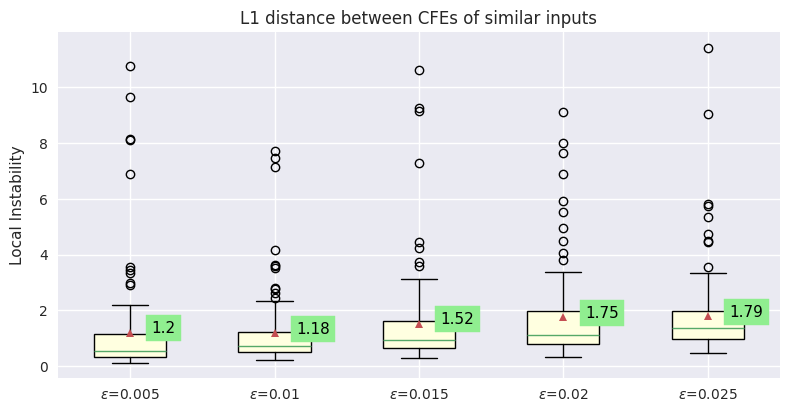

In [44]:
plt.style.use("seaborn-v0_8")
plt.rcParams['figure.figsize'] = [8, 4]

plot_boxplot(data=instability_l1_list, 
             mean_values=np.round(np.mean(pd.DataFrame(instability_l1_list), axis=1), 2),
             tick_labels=[f'$\\epsilon$={noise_level}' for noise_level in noise_magnitudes],
             y_label='Local Instability', 
             colors=['lightyellow'], 
             title='L1 distance between CFEs of similar inputs')

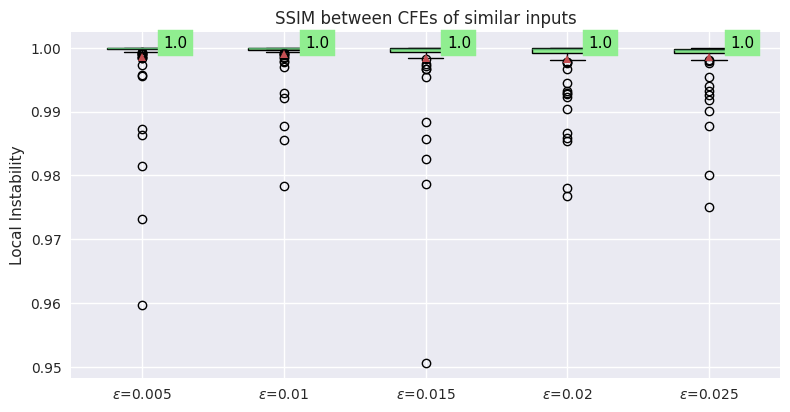

In [45]:
plot_boxplot(data=ssim_list, mean_values=np.round(np.mean(pd.DataFrame(ssim_list), axis=1), 2),
             tick_labels=[f'$\\epsilon$={noise_level}' for noise_level in noise_magnitudes],
             y_label='Local Instability', colors=['lightgreen'], title='SSIM between CFEs of similar inputs')

# Invalidation Rate

In [47]:
classifiers_weights_dir = "/teamspace/studios/this_studio/CF-Robustness-Benchmark/notebooks/experiments/fmnist_classification/multiclass/checkpoints/mc_all"

classifiers_list = []
for clf_weights in os.listdir(classifiers_weights_dir):
    cnn_perturbed = SimpleCNNtorch(**config.classifier.args, 
                                    num_classes=config.data.num_classes)
    load_model_weights(model=cnn_perturbed, 
                        weights_path=osp.join(classifiers_weights_dir, clf_weights),
                        lightning_used=False)
    classifiers_list.append(cnn_perturbed.to(DEVICE))
    evaluate_classification_model(cnn_perturbed, 
                                  dataloader=test_loader, 
                                  num_classes=config.data.num_classes,
                                  device=DEVICE)

Accuracy for the test dataset: 80.680%
Accuracy for the test dataset: 81.672%
Accuracy for the test dataset: 81.597%
Accuracy for the test dataset: 81.052%
Accuracy for the test dataset: 81.176%
Accuracy for the test dataset: 79.886%
Accuracy for the test dataset: 80.556%
Accuracy for the test dataset: 80.630%
Accuracy for the test dataset: 81.076%
Accuracy for the test dataset: 79.712%


In [48]:
validity_list = []
invalidation_rate_list = []

for i, classifier in enumerate(classifiers_list):
    validity = 0
    invalidation_rate = 0
    total_found_cfs = 0
    
    classifier.eval()

    for j, cfe in enumerate(cfes):
        baseline_pred = cfes_preds[j]
        if baseline_pred == TARGET_CLASS_IND:
            cfe = cfe.unsqueeze(0).to(DEVICE)
            total_found_cfs += 1
            
            with torch.no_grad():
                alternative_pred = torch.argmax(classifier(cfe), axis=-1).item()
                # print(baseline_pred, alternative_pred)

            if baseline_pred != alternative_pred:
                invalidation_rate += 1

            if alternative_pred == TARGET_CLASS_IND:
                    validity += 1

    invalidation_rate /= total_found_cfs
    validity /= total_found_cfs 
    invalidation_rate_list.append(invalidation_rate)
    validity_list.append(validity)
    print(f'Model {i}: IR={np.round(invalidation_rate, 4)}, validity={np.round(validity, 4)}')

print('Average IR : {:.3f} +- {:.3f}'.format(np.mean(invalidation_rate_list), np.std(invalidation_rate_list)))
print('Average VaR : {:.3f} +- {:.3f}'.format(np.mean(validity_list), np.std(validity_list)))

Model 0: IR=0.099, validity=0.901
Model 1: IR=0.0594, validity=0.9406
Model 2: IR=0.1287, validity=0.8713
Model 3: IR=0.0693, validity=0.9307
Model 4: IR=0.1188, validity=0.8812
Model 5: IR=0.0891, validity=0.9109
Model 6: IR=0.0495, validity=0.9505
Model 7: IR=0.1287, validity=0.8713
Model 8: IR=0.0396, validity=0.9604
Model 9: IR=0.0693, validity=0.9307
Average IR : 0.085 +- 0.031
Average VaR : 0.915 +- 0.031


In [49]:
k = 1000

average_stability_list = []

for i, classifier in enumerate(classifiers_list):
    stability_list = []
    for j, cfe in enumerate(cfes):
        baseline_pred = cfes_preds[j]
        if baseline_pred == TARGET_CLASS_IND:
            cfe = cfe.unsqueeze(0)
            cfe_sampled = perturb_sample(cfe, n_samples=k, type='normal', 
                                        epsilon=0, std=0.01, channels_first=True)
            cfe_sampled = torch.Tensor(cfe_sampled).squeeze(0)

            with torch.no_grad():
                cf_logits = classifier(cfe.to(DEVICE))
                cf_probabilities = F.softmax(cf_logits, dim=-1)[:, TARGET_CLASS_IND]

                cf_sampled_logits = classifier(cfe_sampled.to(DEVICE))
                cf_sampled_probabilities = F.softmax(cf_sampled_logits, dim=-1)[:, TARGET_CLASS_IND]
            
            model_variance = abs(cf_probabilities - cf_sampled_probabilities)

            stability = (cf_sampled_probabilities - model_variance).mean()
            stability_list.append(stability.item())

    avg_i_stability = np.mean(stability_list)
    print('Stability of the model {}: {:.3f} +- {:.3f}'.format(i, avg_i_stability.item(), np.std(stability_list).item()))
    average_stability_list.append(avg_i_stability)

Stability of the model 0: 0.746 +- 0.229
Stability of the model 1: 0.819 +- 0.193
Stability of the model 2: 0.783 +- 0.237
Stability of the model 3: 0.827 +- 0.218
Stability of the model 4: 0.752 +- 0.262
Stability of the model 5: 0.828 +- 0.208
Stability of the model 6: 0.833 +- 0.204
Stability of the model 7: 0.767 +- 0.233
Stability of the model 8: 0.889 +- 0.188
Stability of the model 9: 0.787 +- 0.222


In [50]:
print('Average RS: {:.3f} +- {:.3f}'.format(np.mean(average_stability_list), np.std(average_stability_list)))

Average RS: 0.803 +- 0.042


# LOF

In [51]:
from src.evaluation.lof import estimate_anom_cfe_in_target_class
from src.utils import extract_factual_instances
from sklearn.neighbors import LocalOutlierFactor

In [52]:
cfes_array = np.stack([cfe.numpy() for i, cfe in enumerate(cfes) if cfes_preds[i] ==  TARGET_CLASS_IND])

In [53]:
lof = LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)
test_imgs, labels = extract_factual_instances(test_loader, init_class_idx=[TARGET_CLASS_IND]) 
factuals_array = test_imgs.reshape(test_imgs.shape[0], np.prod(test_imgs.shape[1:])).numpy()
lof.fit(factuals_array)

LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)

In [33]:
cfes_array = cfes_array.reshape(cfes_array.shape[0], -1)
target_class_ascores = lof.score_samples(cfes_array)
print('LOF score wrt the target class distribution')
print('Average negative LOF (the lower values the more anomaluous): {:.3f} ({:.3f})'.format(np.mean(target_class_ascores), np.std(target_class_ascores)))

anomaly_scores, _ = estimate_anom_cfe_in_target_class(5, [0, 2, 4, 6], -1.1, test_loader, cfes_array)
print('LOF score wrt the test set distribution')
print('Average negative LOF (the lower values the more anomaluous): {:.3f} ({:.3f})'.format(np.mean(anomaly_scores), np.std(anomaly_scores)))

LOF score wrt the target class distribution
Average negative LOF (the lower values the more anomaluous): -1.213 (0.146)
LOF score wrt the test set distribution
Average negative LOF (the lower values the more anomaluous): -1.328 (0.249)
